In [1]:
import pandas as pd 
from scipy import stats

In [2]:
data5 = pd.read_csv('BT5.Nonlinear_data.csv', delimiter=",") 
data5.head()

,x,y
0,0.00000,4.427319
1,0.10101,23.835430
2,0.20202,20.719661
3,0.30303,11.851864
4,0.40404,-14.772347


Sử dụng thư viện scikit-learn để xây dựng mô hình hồi quy tuyến tính. Xác định giá trị y_pred từ mô hình và trực quan hóa dữ liệu , mô hình tìm được

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [4]:
X = data5[['x']].values  # Chuyển thành mảng numpy (dạng cột)
y = data5['y'].values  # Mảng giá trị y

# Chia dữ liệu thành tập train và test (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [5]:
print(X, y)

[[ 0.        ]
 [ 0.1010101 ]
 [ 0.2020202 ]
 [ 0.3030303 ]
 [ 0.4040404 ]
 [ 0.50505051]
 [ 0.60606061]
 [ 0.70707071]
 [ 0.80808081]
 [ 0.90909091]
 [ 1.01010101]
 [ 1.11111111]
 [ 1.21212121]
 [ 1.31313131]
 [ 1.41414141]
 [ 1.51515152]
 [ 1.61616162]
 [ 1.71717172]
 [ 1.81818182]
 [ 1.91919192]
 [ 2.02020202]
 [ 2.12121212]
 [ 2.22222222]
 [ 2.32323232]
 [ 2.42424242]
 [ 2.52525253]
 [ 2.62626263]
 [ 2.72727273]
 [ 2.82828283]
 [ 2.92929293]
 [ 3.03030303]
 [ 3.13131313]
 [ 3.23232323]
 [ 3.33333333]
 [ 3.43434343]
 [ 3.53535354]
 [ 3.63636364]
 [ 3.73737374]
 [ 3.83838384]
 [ 3.93939394]
 [ 4.04040404]
 [ 4.14141414]
 [ 4.24242424]
 [ 4.34343434]
 [ 4.44444444]
 [ 4.54545455]
 [ 4.64646465]
 [ 4.74747475]
 [ 4.84848485]
 [ 4.94949495]
 [ 5.05050505]
 [ 5.15151515]
 [ 5.25252525]
 [ 5.35353535]
 [ 5.45454545]
 [ 5.55555556]
 [ 5.65656566]
 [ 5.75757576]
 [ 5.85858586]
 [ 5.95959596]
 [ 6.06060606]
 [ 6.16161616]
 [ 6.26262626]
 [ 6.36363636]
 [ 6.46464646]
 [ 6.56565657]
 [ 6.66666

In [6]:
# Khởi tạo mô hình
model = LinearRegression()

# Huấn luyện mô hình trên tập train
model.fit(X_train, y_train)

# Dự đoán giá trị trên tập test
y_pred = model.predict(X_test)

In [7]:
print(y_pred)

[165.99505574  95.56279204 135.47440814  76.78085505  74.43311293
  62.69440231  22.78278622 158.95182937  -5.39011926 -28.86754049
  13.39181773  41.56472321 142.51763451  48.60794958 182.4292506
 -19.476572   149.56086087 151.908603    -0.69463501  43.91246533]


In [8]:
from sklearn.metrics import mean_squared_error

In [9]:
# Hệ số hồi quy và intercept
print(f"Hệ số hồi quy (w): {model.coef_[0]}")
print(f"Intercept (b): {model.intercept_}")

# Tính MSE
mse = mean_squared_error(y_test, y_pred)
print(f"Mean Squared Error (MSE): {mse:.4f}")

# Tính RMSE
rmse = np.sqrt(mse)
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Hệ số hồi quy (w): 23.24264702008253
Intercept (b): -28.867540491450598
Mean Squared Error (MSE): 237.5020
Root Mean Squared Error (RMSE): 15.4111


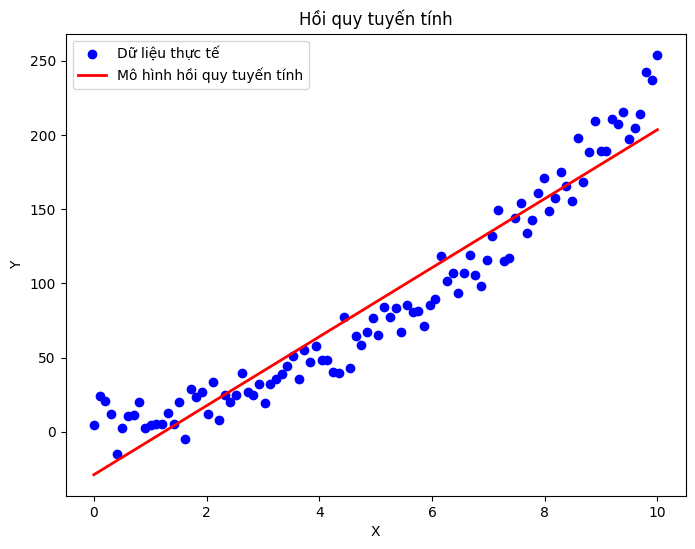

In [10]:
plt.figure(figsize=(8, 6))

# Vẽ dữ liệu gốc
plt.scatter(X, y, color='blue', label='Dữ liệu thực tế')

# Vẽ đường hồi quy tuyến tính
X_line = np.linspace(X.min(), X.max(), 100).reshape(-1, 1)
y_line = model.predict(X_line)
plt.plot(X_line, y_line, color='red', linewidth=2, label='Mô hình hồi quy tuyến tính')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Hồi quy tuyến tính")
plt.legend()
plt.show()

Sử dụng scipy để xây dựng mô hình hồi quy phi tuyến tính (Polinominal). Trực quan hóa mô hình tìm được từ y_pred. Hàm phi tuyến: y = ax2 + bx + c.
Sử dụng curve_fit. Đầu vào x, y là array

In [11]:
from scipy.optimize import curve_fit

In [13]:
# Chuyển đổi thành array
X = data5['x'].values  # Mảng 1D
y = data5['y'].values  # Mảng 1D

In [14]:
def quadratic_function(x, a, b, c):
    return a * x**2 + b * x + c

In [15]:
# Tìm tham số a, b, c
params, covariance = curve_fit(quadratic_function, X, y)

# Lấy giá trị của a, b, c
a, b, c = params
print(f"Hệ số tìm được: a = {a:.4f}, b = {b:.4f}, c = {c:.4f}")

Hệ số tìm được: a = 2.1912, b = 1.0001, c = 7.9493


In [16]:
# Tạo một dải giá trị X để vẽ đường hồi quy mượt hơn
X_smooth = np.linspace(min(X), max(X), 100)

# Tính y_pred dựa trên mô hình tìm được
y_pred = quadratic_function(X_smooth, a, b, c)

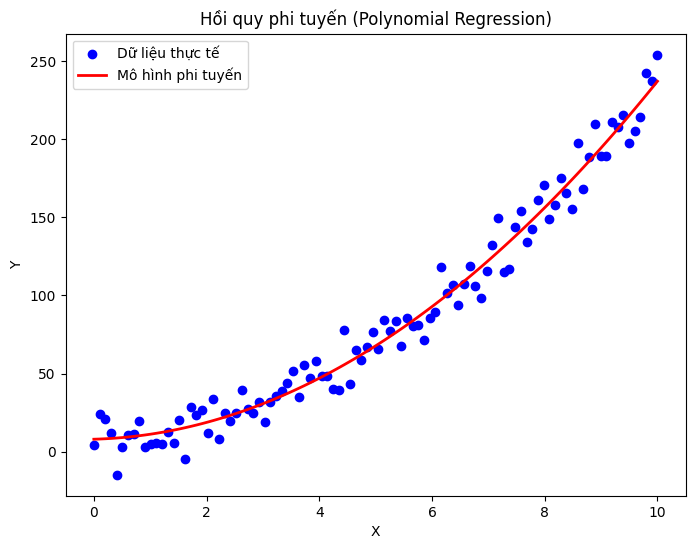

In [17]:
plt.figure(figsize=(8, 6))

# Vẽ dữ liệu thực tế
plt.scatter(X, y, color='blue', label='Dữ liệu thực tế')

# Vẽ đường hồi quy phi tuyến
plt.plot(X_smooth, y_pred, color='red', linewidth=2, label='Mô hình phi tuyến')

plt.xlabel("X")
plt.ylabel("Y")
plt.title("Hồi quy phi tuyến (Polynomial Regression)")
plt.legend()
plt.show()


In [18]:
# Tính MSE
mse = mean_squared_error(y, y_pred)

# Tính RMSE
rmse = np.sqrt(mse)

# In kết quả
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

Mean Squared Error (MSE): 111.8985
Root Mean Squared Error (RMSE): 10.5782
